## How CNNs Clusters data points compared to Transformers

In [6]:
import time
import os
import subprocess
from typing import Dict, Any, List, Tuple
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis

# Try importing user's helper module
try:
    import sys
    sys.path.append('~/robust_cnn_standard')
    from topk_noise_analysis import (
    build_model, make_test_loader, find_best_checkpoint, load_checkpoint_into_model,
    evaluate_topk, print_topk_report
    )
    print("Imported helper functions from ~/robust_cnn_standard")
except Exception as e:
    print("Could not import topk_noise_analysis.py. Ensure the file exists at /mnt/data/topk_noise_analysis.py. Error:", e)


Imported helper functions from ~/robust_cnn_standard


In [7]:
import numpy as np
from collections import defaultdict
from typing import Iterable

In [8]:
def get_module_by_name(model: torch.nn.Module, name: str) -> torch.nn.Module:
    """
    Resolve a submodule by its dotted name (e.g., 'layer4.1.conv2', 'layers.2').
    """
    modules = dict(model.named_modules())
    if name not in modules:
        raise KeyError(
            f"No submodule named '{name}' in model. "
            f"Available keys example: {list(modules.keys())[:20]} ..."
        )
    return modules[name]

# def collect_activations(
#     model: torch.nn.Module,
#     dataloader,
#     layer_names: Iterable[str],
#     device: torch.device,
#     max_batches: int = 50,
# ) -> (Dict[str, np.ndarray], np.ndarray):
#     """
#     Run a forward pass on up to max_batches and collect activations from given layers.

#     Returns:
#       feats_dict: {layer_name : (N, D) numpy array}
#       labels: (N,) numpy array of class indices
#     """
#     model = model.to(device).eval()
#     modules = {name: get_module_by_name(model, name) for name in layer_names}
#     feats = {name: [] for name in layer_names}
#     labels = []

#     handles = []

#     try:
#         def make_hook(name):
#             def hook(_module, _inp, out):
#                 # Flatten all dims except batch dim
#                 if isinstance(out, (tuple, list)):
#                     out = out[0]
#                 feat = out.detach()
                
#                 # feat = feat.view(feat.size(0), -1)  # (B, D)
#                 feat = feat.reshape(feat.size(0),-1)
#                 feats[name].append(feat.cpu())
#             return hook

#         # Register hooks
#         for name, m in modules.items():
#             h = m.register_forward_hook(make_hook(name))
#             handles.append(h)

#         # Forward pass
#         with torch.no_grad():
#             for b_idx, (imgs, targets) in enumerate(dataloader):
#                 imgs = imgs.to(device)
#                 labels.append(targets.clone())
#                 _ = model(imgs)

#                 if b_idx + 1 >= max_batches:
#                     break

#         # Stack all
#         labels = torch.cat(labels, dim=0).cpu().numpy()
#         feats_np = {}

#         for name in layer_names:
#             if len(feats[name]) == 0:
#                 raise RuntimeError(
#                     f"No activations collected for layer {name}. "
#                     "Check that it runs during forward()."
#                 )
#             arr = torch.cat(feats[name], dim=0).numpy()
#             feats_np[name] = arr

#     finally:
#         for h in handles:
#             h.remove()

#     return feats_np, labels


In [9]:
def collect_activations(
    model: nn.Module,
    dataloader,
    layer_names: Iterable[str],
    device: torch.device,
    max_batches: int = 100,
    allowed_labels: Iterable[int] = None,
) -> (Dict[str, np.ndarray], np.ndarray):
    """
    Run a forward pass on up to max_batches and collect activations from given layers.
    If allowed_labels is provided, only samples whose label is in that set are used.
    """
    model = model.to(device).eval()
    modules = {name: get_module_by_name(model, name) for name in layer_names}
    feats = {name: [] for name in layer_names}
    labels = []

    handles = []
    try:
        def make_hook(name):
            def hook(_module, _inp, out):
                if isinstance(out, (tuple, list)):
                    out = out[0]
                feat = out.detach()  # features
                # feat = out.detach().view(out.size(0), -1)
                feat = feat.reshape(feat.size(0),-1)
                feats[name].append(feat.cpu())
            return hook

        # add forward hooks
        for name, m in modules.items():
            handles.append(m.register_forward_hook(make_hook(name)))

        with torch.no_grad():
            for b_idx, (imgs, targets) in enumerate(dataloader):

                # filter batch if needed
                if allowed_labels is not None:
                    mask = torch.tensor([t.item() in allowed_labels for t in targets], dtype=torch.bool)
                    if not mask.any():
                        continue
                    imgs = imgs[mask]
                    targets = targets[mask]

                imgs = imgs.to(device)
                labels.append(targets.clone())
                _ = model(imgs)

                if b_idx + 1 >= max_batches:
                    break

        labels = torch.cat(labels, dim=0).cpu().numpy()
        feats_np = {name: torch.cat(feats[name], dim=0).numpy() for name in layer_names}

    finally:
        for h in handles:
            h.remove()

    return feats_np, labels


In [10]:
def _center_gram(K: np.ndarray) -> np.ndarray:
    """Center a Gram matrix (n x n) in feature space."""
    n = K.shape[0]
    unit = np.ones((n, n), dtype=K.dtype) / n
    return K - unit @ K - K @ unit + unit @ K @ unit


def _gram_linear(X: np.ndarray) -> np.ndarray:
    """Compute linear kernel Gram matrix X X^T."""
    return X @ X.T


def cka_linear(X: np.ndarray, Y: np.ndarray) -> float:
    """Compute linear CKA between two representation matrices.

    X: (n_samples, d1)
    Y: (n_samples, d2)
    """
    # ensure same number of samples
    n = min(X.shape[0], Y.shape[0])
    X = X[:n]
    Y = Y[:n]
    K = _center_gram(_gram_linear(X))
    L = _center_gram(_gram_linear(Y))
    hsic = (K * L).sum()
    var1 = np.sqrt((K * K).sum())
    var2 = np.sqrt((L * L).sum())
    return float(hsic / (var1 * var2 + 1e-12))



In [11]:
import numpy as np
from numpy.linalg import svd, eigh
from typing import Dict

def svcca(X: np.ndarray, Y: np.ndarray, frac: float = 0.99, eps: float = 1e-10) -> float:
    """
    SVCCA-like similarity:
      1) PCA (via SVD) on each matrix, keep components explaining `frac` variance
      2) compute canonical correlations by whitening and SVD of the cross-covariance
      3) return mean canonical correlation (in [0,1])

    X: (N, d1)
    Y: (N, d2)
    """
    # ensure float arrays
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    # center
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)

    # SVD for Xc: Xc = Ux Sx Vx^T
    Ux, Sx, Vx = svd(Xc, full_matrices=False)
    var_x = (Sx ** 2)
    if var_x.sum() <= 0:
        return 0.0
    kx = np.searchsorted(np.cumsum(var_x) / var_x.sum(), frac) + 1
    Xr = Ux[:, :kx] * Sx[:kx]  # (N, kx) scores

    # SVD for Yc
    Uy, Sy, Vy = svd(Yc, full_matrices=False)
    var_y = (Sy ** 2)
    if var_y.sum() <= 0:
        return 0.0
    ky = np.searchsorted(np.cumsum(var_y) / var_y.sum(), frac) + 1
    Yr = Uy[:, :ky] * Sy[:ky]  # (N, ky) scores

    # Compute covariance blocks (note: these are unnormalized; that's fine for whitening)
    Sxx = Xr.T @ Xr  # (kx, kx)
    Syy = Yr.T @ Yr  # (ky, ky)
    Sxy = Xr.T @ Yr  # (kx, ky)

    # Regularized inverse sqrt via eigen-decomposition for stability
    def inv_sqrt_matrix(A):
        # symmetric eigen-decomposition
        A = (A + A.T) / 2.0
        vals, vecs = eigh(A)
        # threshold tiny / negative eigenvalues
        vals_clipped = np.clip(vals, a_min=eps, a_max=None)
        inv_sqrt = vecs @ np.diag(1.0 / np.sqrt(vals_clipped)) @ vecs.T
        return inv_sqrt

    # whiten
    Sxx_inv_sqrt = inv_sqrt_matrix(Sxx)
    Syy_inv_sqrt = inv_sqrt_matrix(Syy)

    # whitened cross-covariance
    T = Sxx_inv_sqrt @ Sxy @ Syy_inv_sqrt  # (kx, ky)

    # SVD of T -> singular values are canonical correlations (in [0,1] numerically)
    _, Svals, _ = svd(T, full_matrices=False)
    # clip to valid range
    Svals = np.clip(Svals, 0.0, 1.0)

    if Svals.size == 0:
        return 0.0
    return float(np.mean(Svals))


In [7]:
def intra_inter_class_variance(features: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """
    Compute intra-class and inter-class variance with per-dimension normalization.

    Returns both per-dimension metrics (recommended) and raw totals (for reference).
    features: (N, D)
    labels: (N,)
    """
    feats = np.asarray(features, dtype=float)
    labels = np.asarray(labels)
    N, D = feats.shape

    classes = np.unique(labels)
    class_means = []
    intra_vars_per_dim = []   # per-class, per-dim variance average (scalar per class)

    for c in classes:
        idx = (labels == c)
        Xc = feats[idx]
        if Xc.shape[0] == 0:
            continue
        # per-dimension variance for this class
        var_per_dim = Xc.var(axis=0, ddof=0)  # shape (D,)
        # mean variance per dimension for this class (scalar)
        intra_vars_per_dim.append(var_per_dim.mean())
        class_means.append(Xc.mean(axis=0))

    class_means = np.stack(class_means, axis=0)  # (K, D)
    global_mean = feats.mean(axis=0)

    # intra-class: mean and std (per-dimension average)
    intra_mean_per_dim = float(np.mean(intra_vars_per_dim)) if len(intra_vars_per_dim) > 0 else 0.0
    intra_std_per_dim = float(np.std(intra_vars_per_dim)) if len(intra_vars_per_dim) > 0 else 0.0

    # inter-class variance: variance of class means per-dimension (then averaged over dims)
    inter_var_per_dim = np.var(class_means, axis=0, ddof=0)  # (D,)
    inter_mean_per_dim = float(inter_var_per_dim.mean())

    # For completeness, also compute the raw (sum-of-squares) quantities you had before
    intra_raw_list = []
    for c in classes:
        idx = (labels == c)
        Xc = feats[idx]
        if Xc.shape[0] == 0:
            continue
        mu_c = Xc.mean(axis=0)
        intra_raw = ((Xc - mu_c) ** 2).sum(axis=1).mean()  # per-sample sum across dims
        intra_raw_list.append(intra_raw)
    intra_raw_mean = float(np.mean(intra_raw_list)) if len(intra_raw_list) > 0 else 0.0
    inter_raw = ((class_means - global_mean) ** 2).sum(axis=1).mean() if class_means.shape[0] > 0 else 0.0

    return {
        'intra_class_variance_per_dim_mean': intra_mean_per_dim,
        'intra_class_variance_per_dim_std': intra_std_per_dim,
        'inter_class_variance_per_dim': inter_mean_per_dim,
        'intra_class_variance_raw_mean': intra_raw_mean,
        'inter_class_variance_raw': float(inter_raw),
        'num_classes': int(len(classes)),
        'feature_dim': int(D)
    }


In [12]:
from sklearn.manifold import TSNE
import umap

def compute_embedding_2d(features: np.ndarray, method: str = 'tsne', random_state: int = 42) -> np.ndarray:
    """Project features to 2D using t-SNE or UMAP.

    method: 'tsne' or 'umap'
    """
    if method == 'tsne':
        if TSNE is None:
            raise ImportError("TSNE not available. Install scikit-learn.")
        emb = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=random_state).fit_transform(features)
    elif method == 'umap':
        if umap is None:
            raise ImportError("umap not available. Install umap-learn.")
        reducer = umap.UMAP(n_components=2, random_state=random_state)
        emb = reducer.fit_transform(features)
    else:
        raise ValueError("Unknown method: {}".format(method))
    return emb



/var/tmp/system-private-cache-user/thcr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_dir = '/var/tmp/system-private-cache-user/phd_work/data/tamil/test/'


# Choose a subset of test data to keep representation analysis tractable
loader, num_classes_ds, classes, class_to_idx = make_test_loader(test_dir, batch_size=64, num_workers=4)


# Example: ResNet-50 last block vs Swin-T final norm
cnn_name = 'convnext_tiny'
trf_name = 'squeezenet1_0'
cnn_ckpt = './outputs/convnext_tiny/checkpoints/best.pt'
trf_ckpt = './outputs/squeezenet1_0/checkpoints/best.pt'


# Build models
cnn = build_model(cnn_name, num_classes=num_classes_ds, pretrained=False)
trf = build_model(trf_name, num_classes=num_classes_ds, pretrained=False)
_ = load_checkpoint_into_model(cnn, cnn_ckpt)
_ = load_checkpoint_into_model(trf, trf_ckpt)

model
model


In [17]:
from torch_cka import CKA

In [ ]:
cka = CKA(model1=cnn, model2=trf,
          model1_name="ConvNext",   # good idea to provide names to avoid confusion
          model2_name="SqueezeNet",            
          device='cuda')

cka.compare(loader) # secondary dataloader is optional

results = cka.export() 
cka.plot_results(save_path="cka_convnext_squeezenet.png")

/var/tmp/system-private-cache-user/thcr/lib/python3.10/site-packages/torch_cka/cka.py:145: UserWarning: Dataloader for Model 2 is not given. Using the same dataloader for both models.
  warn("Dataloader for Model 2 is not given. Using the same dataloader for both models.")
| Comparing features |:   0%|          | 1/439 [00:13<1:40:48, 13.81s/it]

In [16]:
# for name in cnn.named_modules():
#     print(name)

In [13]:
# You must inspect model structure and choose layer names appropriately.
# For example (adjust to your actual architectures):
cnn_layers = ['features.7.2.block.5',] # last ResNet block
trf_layers = ['classifier.1'] # last Swin stage

# select top-15 confused classes
selected_classes = ['010','038','041','072','114','117',
                    '125','128','129','130','135','136',
                    '147','151','152']
# select top-5


allowed_labels = [class_to_idx[c] for c in selected_classes]

cnn_feats, labels = collect_activations(cnn, loader, cnn_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)
trf_feats, _ = collect_activations(trf, loader, trf_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)


X_cnn = cnn_feats[cnn_layers[0]]
X_trf = trf_feats[trf_layers[0]]


# Linear CKA between CNN and Transformer
cka_val = cka_linear(X_cnn, X_trf)
print(f"Linear CKA between {cnn_name}:{cnn_layers[0]} and {trf_name}:{trf_layers[0]} = {cka_val:.4f}")


# SVCCA
svcca_val = svcca(X_cnn, X_trf, frac=0.99)
print(f"SVCCA between {cnn_name} and {trf_name} = {svcca_val:.4f}")


# Variance statistics for each model
stats_cnn = intra_inter_class_variance(X_cnn, labels)
stats_trf = intra_inter_class_variance(X_trf, labels)
print('CNN variance stats:', stats_cnn)
print('Transformer variance stats:', stats_trf)


# 2D embeddings (e.g., visualize a subset of classes)
subset_idx = np.random.choice(X_cnn.shape[0], size=min(2000, X_cnn.shape[0]), replace=False)
emb_cnn = compute_embedding_2d(X_cnn[subset_idx], method='tsne')
emb_trf = compute_embedding_2d(X_trf[subset_idx], method='tsne')


# You can now plot emb_cnn / emb_trf colored by labels[subset_idx] to visually compare clustering
# (do this in a separate cell with matplotlib).

Linear CKA between convnext_tiny:features.7 and squeezenet1_0:classifier.1 = 0.6431
SVCCA between convnext_tiny and squeezenet1_0 = 0.8410
CNN variance stats: {'intra_class_variance_per_dim_mean': 3.362246178735823, 'intra_class_variance_per_dim_std': 1.159818449782939, 'inter_class_variance_per_dim': 3.1106271218479007, 'intra_class_variance_raw_mean': 126528.04819818647, 'inter_class_variance_raw': 117059.13932500873, 'num_classes': 15, 'feature_dim': 37632}
Transformer variance stats: {'intra_class_variance_per_dim_mean': 1264.5545922195968, 'intra_class_variance_per_dim_std': 186.82554149305193, 'inter_class_variance_per_dim': 936.052768954519, 'intra_class_variance_raw_mean': 33338717.26927745, 'inter_class_variance_raw': 24678099.53935418, 'num_classes': 15, 'feature_dim': 26364}


In [14]:
allowed_labels

[10, 38, 41, 72, 114, 117, 125, 128, 129, 130, 135, 136, 147, 151, 152]

In [15]:
len(subset_idx)

2000

In [16]:
help(make_test_loader)

Help on function make_test_loader in module topk_noise_analysis:

make_test_loader(test_dir: str, batch_size: int = 128, num_workers: int = 4, invert: bool = False, add_noise: bool = False, noise_std: float = 8.0)



In [17]:
import matplotlib.pyplot as plt
import numpy as np

# def plot_cnn_vs_transformer_embeddings(
#     emb_cnn: np.ndarray,
#     emb_trf: np.ndarray,
#     labels: np.ndarray,
#     num_classes_to_label: int = 10,
#     title_cnn: str = "CNN Feature Space",
#     title_trf: str = "Transformer Feature Space",
#     figsize=(12, 5)
# ):
#     """
#     emb_cnn: (N,2) t-SNE or UMAP embedding for CNN
#     emb_trf: (N,2) t-SNE or UMAP embedding for Transformer
#     labels: (N,) int class labels
#     num_classes_to_label: how many random classes to highlight in legend
#     """

#     # unique label set
#     classes = np.unique(labels)

#     # build a fixed colormap
#     cmap = plt.get_cmap("tab20")  # good for up to 20 unique colors

#     # optionally pick a random subset of classes to show in legend
#     if len(classes) > num_classes_to_label:
#         sampled_classes = np.random.choice(classes, size=num_classes_to_label, replace=False)
#     else:
#         sampled_classes = classes

#     fig, axes = plt.subplots(1, 2, figsize=figsize)

#     # -----------------------------------------------------------------------
#     # Left: CNN embedding
#     # -----------------------------------------------------------------------
#     ax = axes[0]
#     for c in classes:
#         idx = (labels == c)
#         color = cmap(int(c) % 20)  # wrap around if > 20 classes
#         ax.scatter(
#             emb_cnn[idx, 0],
#             emb_cnn[idx, 1],
#             s=5,
#             alpha=0.6,
#             color=color,
#             label=str(c) if c in sampled_classes else None,
#         )

#     ax.set_title(title_cnn, fontsize=14)
#     ax.set_xticks([])
#     ax.set_yticks([])

#     # -----------------------------------------------------------------------
#     # Right: Transformer embedding
#     # -----------------------------------------------------------------------
#     ax = axes[1]
#     for c in classes:
#         idx = (labels == c)
#         color = cmap(int(c) % 20)
#         ax.scatter(
#             emb_trf[idx, 0],
#             emb_trf[idx, 1],
#             s=5,
#             alpha=0.6,
#             color=color,
#             label=str(c) if c in sampled_classes else None,
#         )

#     ax.set_title(title_trf, fontsize=14)
#     ax.set_xticks([])
#     ax.set_yticks([])

#     # -----------------------------------------------------------------------
#     # Legend (shared)
#     # -----------------------------------------------------------------------
#     handles, class_labels = axes[1].get_legend_handles_labels()
#     if len(class_labels) > 0:
#         fig.legend(
#             handles,
#             class_labels,
#             title="Classes",
#             loc="upper center",
#             bbox_to_anchor=(0.5, 0.04),
#             ncol=min(len(class_labels), num_classes_to_label),
#         )

#     plt.tight_layout()
#     plt.show()


# Improved: Display labels at the center

In [19]:

def plot_cnn_vs_transformer_embeddings(
    emb_cnn: np.ndarray,
    emb_trf: np.ndarray,
    labels: np.ndarray,
    num_classes_to_label: int = 10,
    title_cnn: str = "CNN Feature Space",
    title_trf: str = "Transformer Feature Space",
    figsize=(12, 5)
):
    """
    emb_cnn: (N,2) t-SNE or UMAP embedding for CNN
    emb_trf: (N,2) t-SNE or UMAP embedding for Transformer
    labels: (N,) int class labels
    num_classes_to_label: how many random classes to include in the legend
    """

    classes = np.unique(labels)
    cmap = plt.get_cmap("tab20")

    # Legend sampling
    if len(classes) > num_classes_to_label:
        sampled_classes = np.random.choice(classes, size=num_classes_to_label, replace=False)
    else:
        sampled_classes = classes

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ============================================================
    # Left Panel — CNN
    # ============================================================
    ax = axes[0]
    for c in classes:
        idx = (labels == c)
        color = cmap(int(c) % 20)
        ax.scatter(
            emb_cnn[idx, 0],
            emb_cnn[idx, 1],
            s=5,
            alpha=0.6,
            color=color,
            label=str(c) if c in sampled_classes else None,
        )

        # ---- Add cluster center label ----
        cx, cy = emb_cnn[idx, 0].mean(), emb_cnn[idx, 1].mean()
        ax.text(
            cx, cy, str(c),
            fontsize=9, weight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8, lw=0.5)
        )

    ax.set_title(title_cnn, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

    # ============================================================
    # Right Panel — Transformer
    # ============================================================
    if emb_trf is not None:
        ax = axes[1]
        for c in classes:
            idx = (labels == c)
            color = cmap(int(c) % 20)
            ax.scatter(
                emb_trf[idx, 0],
                emb_trf[idx, 1],
                s=5,
                alpha=0.6,
                color=color,
                label=str(c) if c in sampled_classes else None,
            )
    
            # ---- Add cluster center label ----
            cx, cy = emb_trf[idx, 0].mean(), emb_trf[idx, 1].mean()
            ax.text(
                cx, cy, str(c),
                fontsize=9, weight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8, lw=0.5)
            )
    
        ax.set_title(title_trf, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    # ============================================================
    # Legend (shared)
    # ============================================================
    handles, class_labels = axes[0].get_legend_handles_labels()
    if len(class_labels) > 0:
        fig.legend(
            handles,
            class_labels,
            title="Classes",
            loc="upper center",
            bbox_to_anchor=(0.5, 0.04),
            ncol=min(len(class_labels), num_classes_to_label),
        )

    plt.tight_layout()
    plt.show()


Top-15 misclassified classes

In [16]:
# subset_idx = np.random.choice(X_cnn.shape[0], size=min(2000, X_cnn.shape[0]), replace=False)
# emb_cnn = compute_embedding_2d(X_cnn[subset_idx], method="tsne")
# emb_trf = compute_embedding_2d(X_trf[subset_idx], method="tsne")
# labels_subset = labels[subset_idx]

In [20]:
labels_subset = labels[subset_idx]

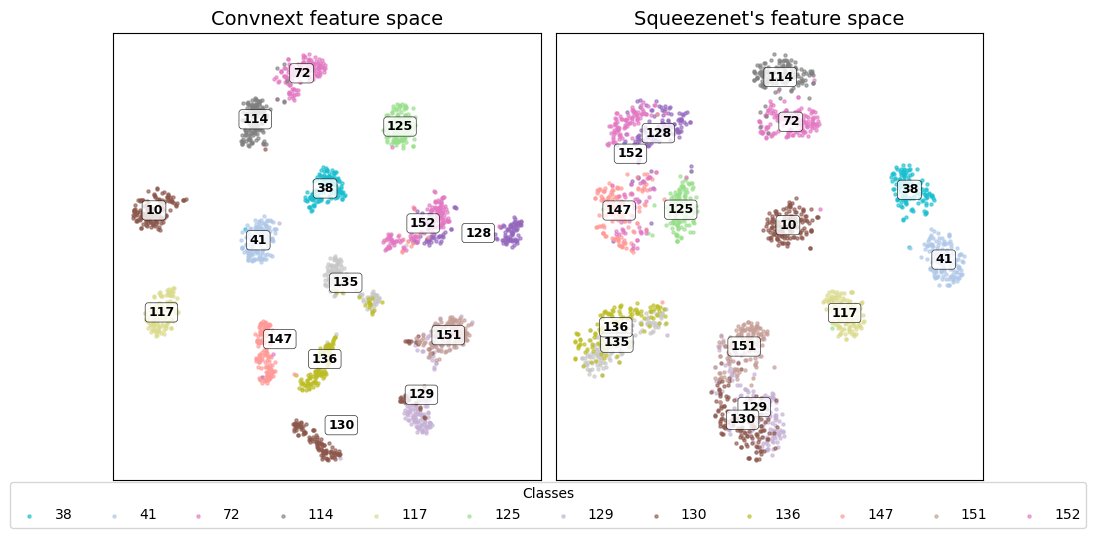

In [22]:
plot_cnn_vs_transformer_embeddings(
    emb_cnn,
    emb_trf,
    labels_subset,
    num_classes_to_label=12,
    title_cnn="Convnext feature space",
    title_trf="Squeezenet's feature space",
    figsize=(9, 5)
)


## After Adding noise

In [23]:
# Choose a subset of test data to keep representation analysis tractable
loader, num_classes_ds, classes, class_to_idx = make_test_loader(test_dir, batch_size=64, num_workers=4,add_noise=True,noise_std=30)

In [24]:
cnn_layers = ['features.7'] # last ResNet block
trf_layers = ['classifier.1'] # last Swin stage

# select top-15 confused classes
selected_classes = ['010','038','041','072','114','117',
                    '125','128','129','130','135','136',
                    '147','151','152']


allowed_labels = [class_to_idx[c] for c in selected_classes]

cnn_feats, labels = collect_activations(cnn, loader, cnn_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)
trf_feats, _ = collect_activations(trf, loader, trf_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)


X_cnn_noise = cnn_feats[cnn_layers[0]]
X_trf_noise = trf_feats[trf_layers[0]]


# Linear CKA between CNN and Transformer
cka_val = cka_linear(X_cnn_noise, X_trf_noise)
print(f"Linear CKA between {cnn_name}:{cnn_layers[0]} and {trf_name}:{trf_layers[0]} = {cka_val:.4f}")


# SVCCA
svcca_val = svcca(X_cnn_noise, X_trf_noise, frac=0.99)
print(f"SVCCA between {cnn_name} and {trf_name} = {svcca_val:.4f}")


# Variance statistics for each model
stats_cnn = intra_inter_class_variance(X_cnn_noise, labels)
stats_trf = intra_inter_class_variance(X_trf_noise, labels)
print('CNN variance stats:', stats_cnn)
print('Transformer variance stats:', stats_trf)





Linear CKA between convnext_tiny:features.7 and squeezenet1_0:classifier.1 = 0.6431
SVCCA between convnext_tiny and squeezenet1_0 = 0.8445
CNN variance stats: {'intra_class_variance_per_dim_mean': 3.3637454995733718, 'intra_class_variance_per_dim_std': 1.1614808035202442, 'inter_class_variance_per_dim': 3.102860602412587, 'intra_class_variance_raw_mean': 126584.47063994514, 'inter_class_variance_raw': 116766.86965685037, 'num_classes': 15, 'feature_dim': 37632}
Transformer variance stats: {'intra_class_variance_per_dim_mean': 1083.6767988633142, 'intra_class_variance_per_dim_std': 142.67748953240374, 'inter_class_variance_per_dim': 792.0254487304908, 'intra_class_variance_raw_mean': 28570055.125232413, 'inter_class_variance_raw': 20880962.560517203, 'num_classes': 15, 'feature_dim': 26364}


In [26]:
# 2D embeddings (e.g., visualize a subset of classes)
# subset_idx = np.random.choice(X_cnn.shape[0], size=min(2000, X_cnn.shape[0]), replace=False)
emb_cnn_noise = compute_embedding_2d(X_cnn_noise[subset_idx], method='tsne') # change method to umap if required
emb_trf_noise = compute_embedding_2d(X_trf_noise[subset_idx], method='tsne')

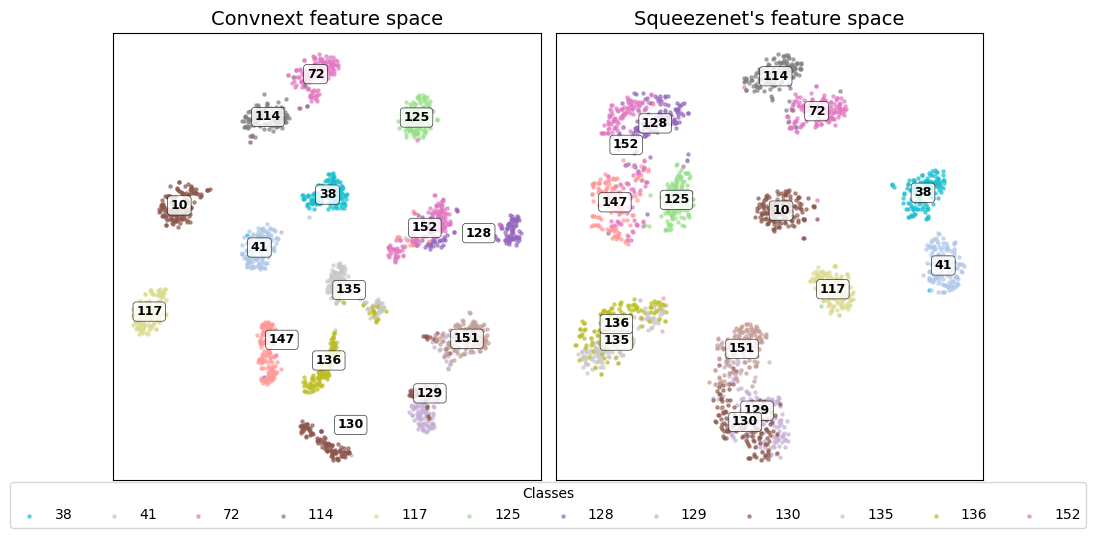

In [27]:
plot_cnn_vs_transformer_embeddings(
    emb_cnn_noise,
    emb_trf_noise,
    labels_subset,
    num_classes_to_label=12,
    title_cnn="Convnext feature space",
    title_trf="Squeezenet's feature space",
    figsize=(9, 5)
)

## Mnasnet
* What happens to the representation if we add noise? Mode collapse. let's explore

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_dir = '/var/tmp/system-private-cache-user/phd_work/data/tamil/test/'


# Choose a subset of test data to keep representation analysis tractable
loader, num_classes_ds, classes, class_to_idx = make_test_loader(test_dir, batch_size=64, num_workers=4)


# Example: ResNet-50 last block vs Swin-T final norm
cnn_name = 'mnasnet0_5'
cnn_ckpt = './outputs/mnasnet0_5/checkpoints/best.pt'


# Build models
cnn = build_model(cnn_name, num_classes=num_classes_ds, pretrained=False)

_ = load_checkpoint_into_model(cnn, cnn_ckpt)


model


In [30]:
# for name in cnn.named_modules():
#     print(name)

In [31]:
# You must inspect model structure and choose layer names appropriately.
# For example (adjust to your actual architectures):
cnn_layers = ['layers.14'] # last mnasnet block


# select top-15 confused classes
selected_classes = ['010','038','041','072','114','117',
                    '125','128','129','130','135','136',
                    '147','151','152']


allowed_labels = [class_to_idx[c] for c in selected_classes]

cnn_feats, labels = collect_activations(cnn, loader, cnn_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)


X_cnn = cnn_feats[cnn_layers[0]]
# X_trf = trf_feats[trf_layers[0]]

subset_idx = np.random.choice(X_cnn.shape[0], size=min(2000, X_cnn.shape[0]), replace=False)
emb_cnn = compute_embedding_2d(X_cnn[subset_idx], method='tsne')

In [32]:
labels_subset = labels[subset_idx]

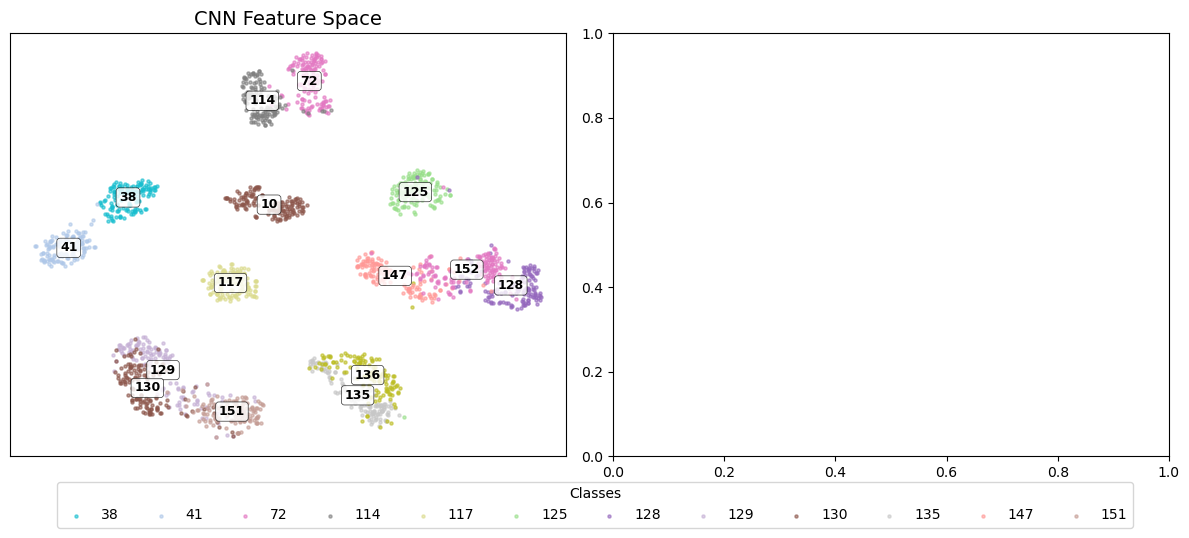

In [33]:
plot_cnn_vs_transformer_embeddings(
    emb_cnn,
    None,
    labels_subset,
    num_classes_to_label=12
)

## After Adding noise
* Result: t-SNE or UMAP could not cluster meaningfuly in 2d

In [34]:
# Choose a subset of test data to keep representation analysis tractable
loader, num_classes_ds, classes, class_to_idx = make_test_loader(test_dir, batch_size=64, num_workers=4,add_noise=True,noise_std=30)


cnn_layers = ['layers.14'] # last efficientnet block


# select top-15 confused classes
selected_classes = ['010','038','041','072','114','117',
                    '125','128','129','130','135','136',
                    '147','151','152']


allowed_labels = [class_to_idx[c] for c in selected_classes]

cnn_feats, labels = collect_activations(cnn, loader, cnn_layers, device=device, max_batches=1000,allowed_labels=allowed_labels)


X_cnn_noise = cnn_feats[cnn_layers[0]]
# X_trf = trf_feats[trf_layers[0]]

# subset_idx = np.random.choice(X_cnn.shape[0], size=min(2000, X_cnn.shape[0]), replace=False)
emb_cnn_noise = compute_embedding_2d(X_cnn_noise[subset_idx], method='tsne')

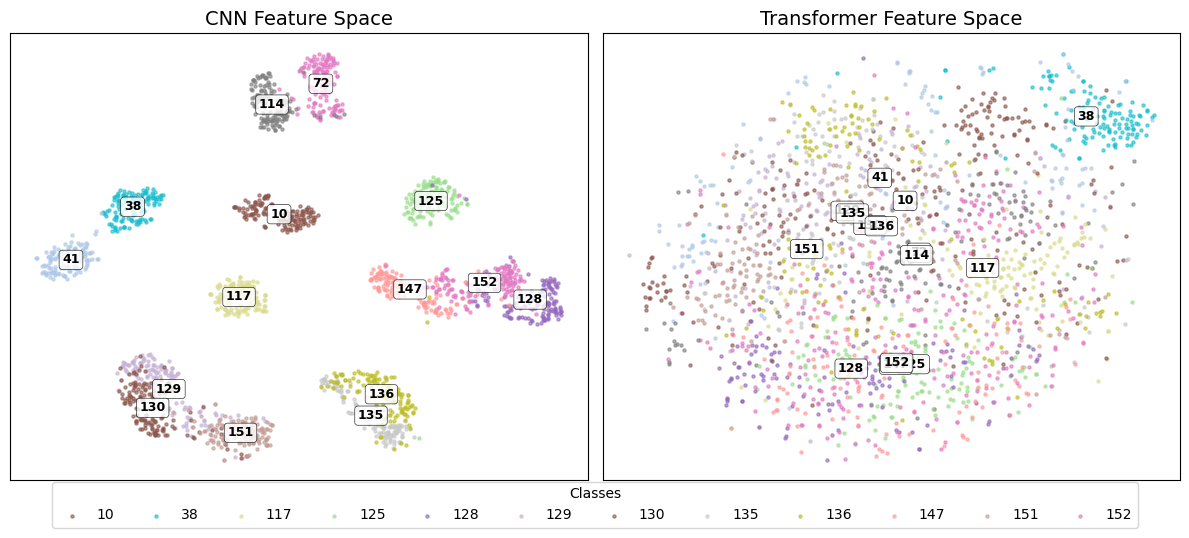

In [35]:
plot_cnn_vs_transformer_embeddings(
    emb_cnn,
    emb_cnn_noise,
    labels_subset,
    num_classes_to_label=12
)

## Raw Image T-SNE

skip: /var/tmp/system-private-cache-user/phd_work/data/tamil/test/151/.ipynb_checkpoints [Errno 21] Is a directory: '/var/tmp/system-private-cache-user/phd_work/data/tamil/test/151/.ipynb_checkpoints'
Loaded: (2700, 4096) images


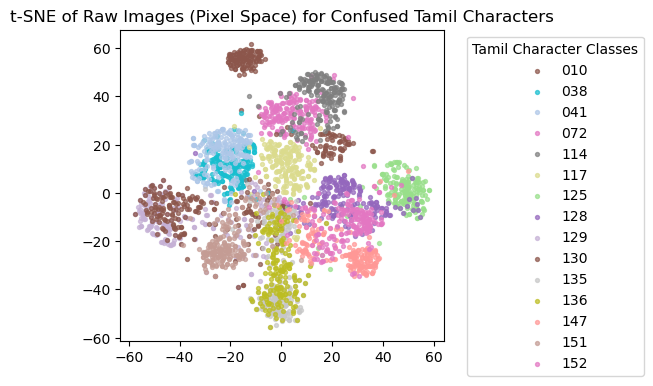

In [117]:
import os
import numpy as np
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def load_raw_images_for_classes(root_dir, class_folders, img_size=(64,64)):
    """
    root_dir: path to dataset/tamil/train or test
    class_folders: ['010','038', ...]
    img_size: resize all images to same resolution for t-SNE
    """
    X = []
    y = []
    paths = []

    for cls in class_folders:
        cls_dir = os.path.join(root_dir, cls)
        files = sorted(os.listdir(cls_dir))

        for f in files:
            fp = os.path.join(cls_dir, f)
            try:
                img = Image.open(fp).convert("L")  # use grayscale consistency
                img = img.resize(img_size)
                arr = np.array(img).astype(np.float32) / 255.0
                X.append(arr.flatten())  # flatten raw pixels
                y.append(cls)
                paths.append(fp)
            except Exception as e:
                print("skip:", fp, e)
    
    X = np.array(X)
    return X, np.array(y), paths


# -----------------------------------------------
# Parameters
# -----------------------------------------------
selected_classes = [
    '010','038','041','072','114','117',
    '125','128','129','130','135','136',
    '147','151','152'
]

root_dir = "/var/tmp/system-private-cache-user/phd_work/data/tamil/test/"  # or train
img_size = (64, 64)

# -----------------------------------------------
# Load raw image pixels
# -----------------------------------------------
X_raw, y_raw, img_paths = load_raw_images_for_classes(
    root_dir,
    selected_classes,
    img_size=img_size
)

print("Loaded:", X_raw.shape, "images")

# -----------------------------------------------
# Run t-SNE
# -----------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X2d = tsne.fit_transform(X_raw)

# -----------------------------------------------
# Plot
# -----------------------------------------------
plt.figure(figsize=(6, 4))
classes = np.unique(y_raw)
cmap = plt.get_cmap("tab20")

for cls in classes:
    idx = (y_raw == cls)
    plt.scatter(
        X2d[idx,0],
        X2d[idx,1],
        s=8,
        alpha=0.7,
        color=cmap(int(cls) % 20),
        label=cls
    )

plt.legend(
    title="Tamil Character Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.title("t-SNE of Raw Images (Pixel Space) for Confused Tamil Characters")
plt.tight_layout()
plt.show()


Loaded 15 class images.


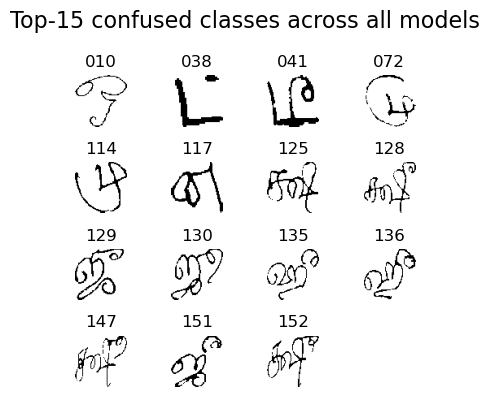

In [115]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------
# EDIT THIS
# ----------------------

selected_classes = [
    '010','038','041','072',
    '114','117','125','128',
    '129','130','135','136',
    '147','151','152'
]

# ----------------------
# Load one image per class
# ----------------------
images = []
labels = []

for cls in selected_classes:
    cls_dir = os.path.join(root_dir, cls)
    if not os.path.isdir(cls_dir):
        print(f"Warning: folder not found → {cls_dir}")
        continue
    
    # find first image file
    files = sorted([f for f in os.listdir(cls_dir) 
                    if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
    
    if len(files) == 0:
        print(f"No images found in {cls_dir}")
        continue
    
    img_path = os.path.join(cls_dir, files[0])
    img = Image.open(img_path).convert("L")  # convert to grayscale (use "RGB" if needed)
    
    images.append(img)
    labels.append(cls)

print("Loaded", len(images), "class images.")

# ----------------------
# Display in a 4×4 grid
# ----------------------
fig, axes = plt.subplots(4, 4, figsize=(4, 4))
axes = axes.flatten()

for ax, img, label in zip(axes, images, labels):
    ax.imshow(img, cmap="gray")
    ax.set_title(label, fontsize=12)
    ax.axis("off")

# hide any remaining empty subplots
for i in range(len(images), 16):
    axes[i].axis("off")

plt.suptitle("Top-15 confused classes across all models", fontsize=16)
plt.tight_layout()
plt.show()
